In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

from src.utils.config import load_config
from src.models.model import ReconstructionModel

In [3]:
config = load_config("../configs/config.yaml")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ReconstructionModel(config).to(device)
model.load_state_dict(torch.load("../outputs/model_best.pth", map_location=device))
model.eval()

c:\Shivansh\aiml\shapenet\venv_shapenet\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Shivansh\aiml\shapenet\venv_shapenet\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ReconstructionModel(
  (encoder): Encoder(
    (stem): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, 

In [4]:
transform = transforms.Compose([
    transforms.Resize((config["data"]["image_size"], config["data"]["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [5]:
def show_voxel(voxel, threshold=0.5, is_pred=True):

    voxel = voxel.squeeze()

    voxel = np.rot90(voxel, k=1, axes=(1, 2))

    if is_pred:
        voxel = 1 / (1 + np.exp(-voxel))   # sigmoid
        voxel = (voxel > threshold)
    else:
        voxel = voxel.astype(bool)  # GT already binary

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.voxels(voxel, edgecolor='k')
    plt.show()

test samples: 678
--- Sample 352 ---
📷 Input Image


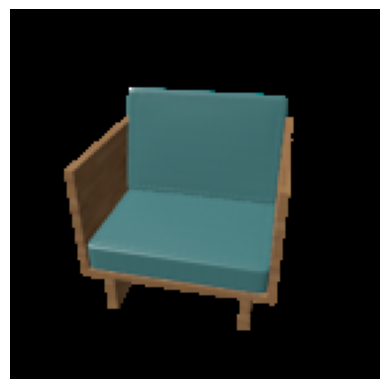

🔵 Predicted Voxel


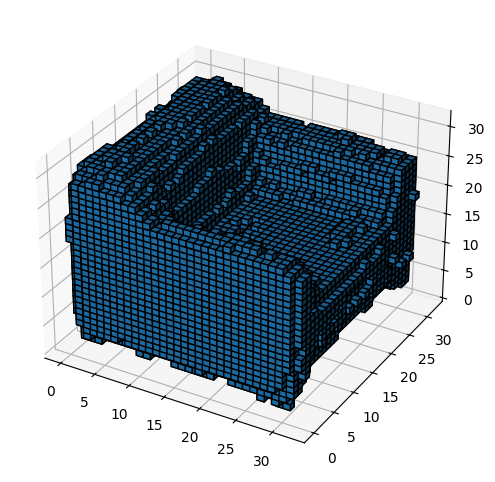

🟢 Ground Truth Voxel


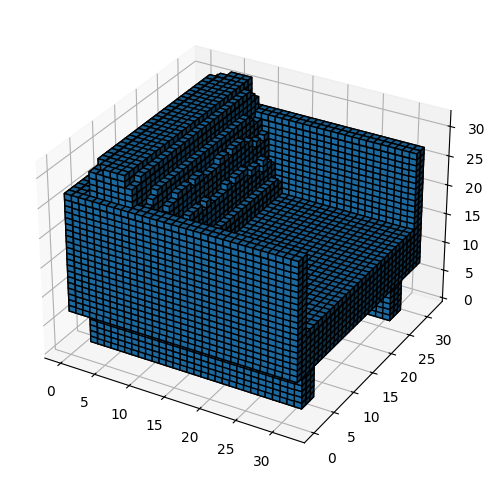

--- Sample 140 ---
📷 Input Image


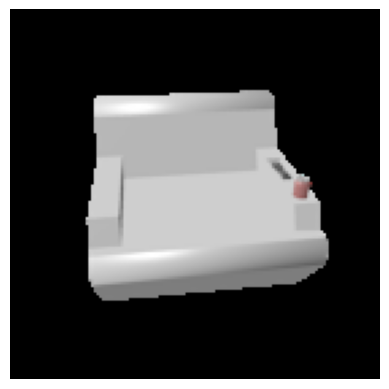

🔵 Predicted Voxel


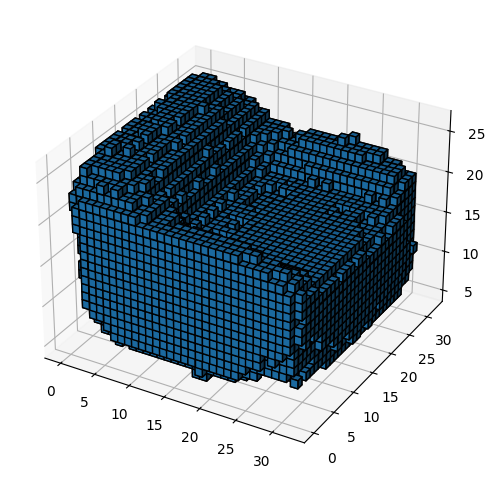

🟢 Ground Truth Voxel


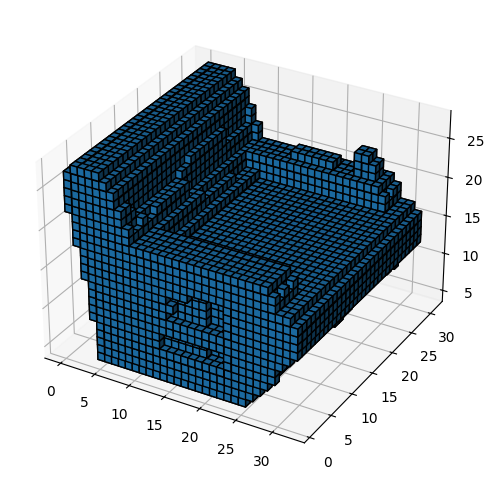

--- Sample 513 ---
📷 Input Image


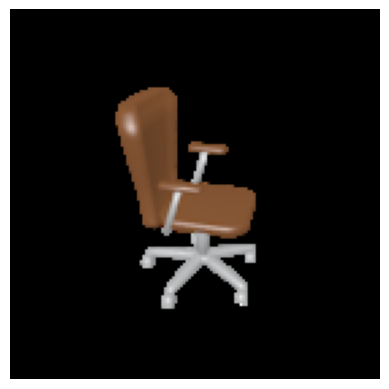

🔵 Predicted Voxel


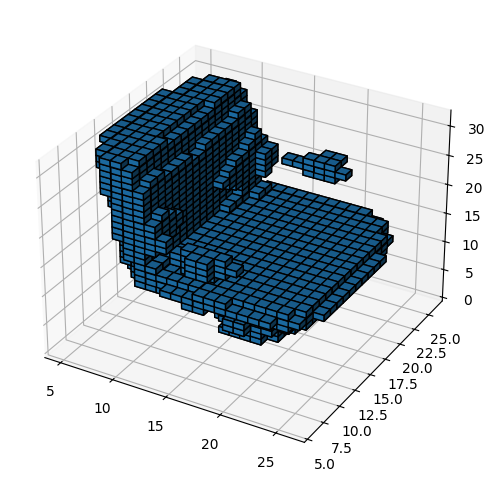

🟢 Ground Truth Voxel


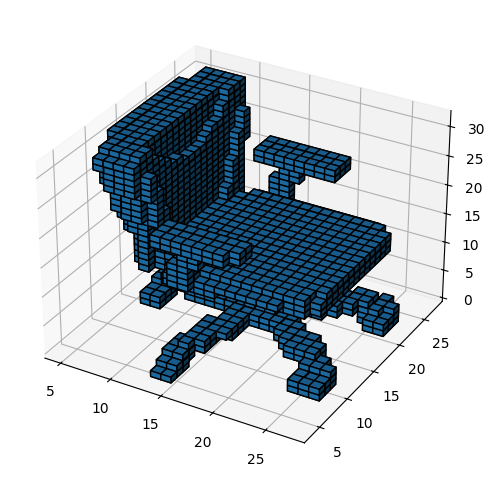

--- Sample 141 ---
📷 Input Image


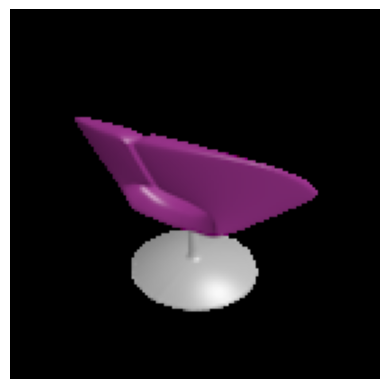

🔵 Predicted Voxel


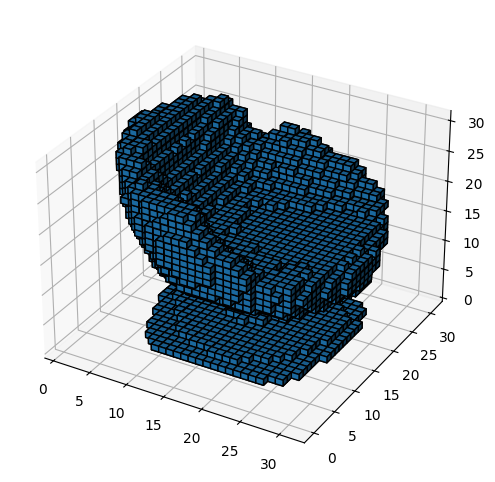

🟢 Ground Truth Voxel


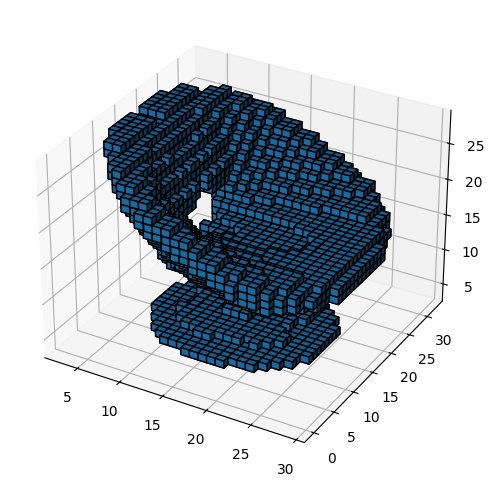

--- Sample 267 ---
📷 Input Image


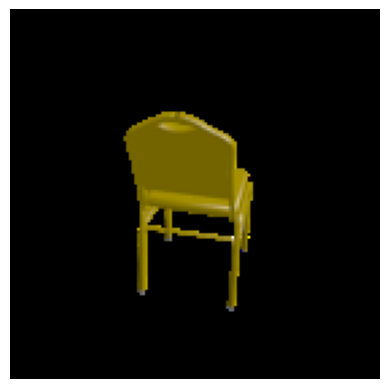

🔵 Predicted Voxel


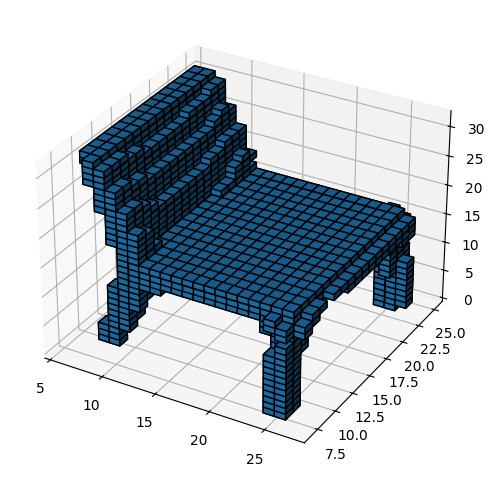

🟢 Ground Truth Voxel


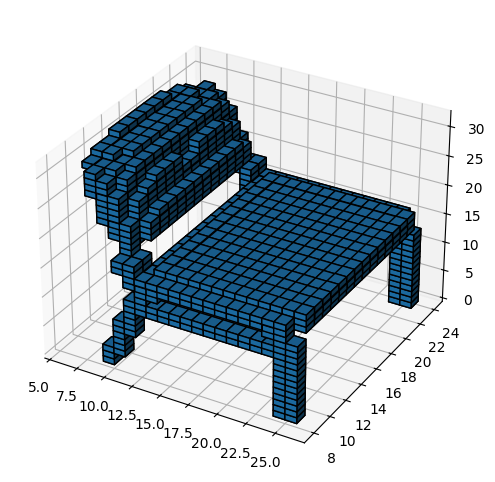

In [9]:
from src.data.dataloader import get_dataloader
import torch

# 1. Load the test dataset
test_loader = get_dataloader(config, "test")
dataset = test_loader.dataset

# 2. Pick random samples each run
num_samples = 5
sample_indices = torch.randperm(len(dataset))[:num_samples].tolist()

with torch.no_grad():
    for i in sample_indices:
        image_paths, voxel_path = dataset.samples[i]
        _, voxel_gt = dataset[i]
        
        # Show first image
        img = Image.open(image_paths[0]).convert("RGB")
        
        # Load ALL views
        all_views = []
        for path in image_paths:
            v_img = Image.open(path).convert("RGB")
            all_views.append(transform(v_img))
            
        # Stack views
        img_tensor = torch.stack(all_views).unsqueeze(0).to(device) 
        
        # Predict
        preds = model(img_tensor)
        
        print(f"--- Sample {i} ---")
        
        # 📷 Input Image
        print("📷 Input Image")
        plt.imshow(img)
        plt.axis("off")
        plt.show()
        
        # 🔵 Predicted Voxel
        print("🔵 Predicted Voxel")
        show_voxel(preds.cpu().numpy(), threshold=0.5, is_pred=True)
        
        # 🟢 Ground Truth
        print("🟢 Ground Truth Voxel")
        show_voxel(voxel_gt.numpy(), is_pred=False)